# Car Price Prediction with Machine Learning 

- Objective
    - The main goal of this project is to predict the selling price of used cars based on their features


- Dataset Features:
    - Car_Name → Brand/model of car 
    - Year → Year of purchase (converted to "Car Age")
    - Selling_Price → Target variable (price of used car in lakhs)
    - Present_Price → Current showroom price of the new car
    - Driven_kms → Distance travel by car usage
    - Fuel_Type → Petrol/Diesel/CNG
    - Selling_type → Dealer/Individual.
    - Transmission → Manual/Automatic.
    - Owner → Number of previous owners.


## 1. Import Libraries & Load Data

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [71]:
df = pd.read_csv(r'C:\Users\USER\Desktop\git hub\Car Price Prediction\car data.csv')

## 2. Data preprocessing

In [72]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [73]:
df.shape

(301, 9)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [75]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [76]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [77]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

In [78]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

### Visualization

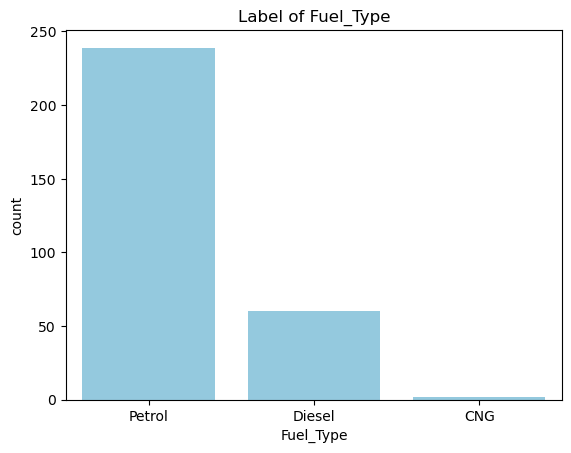

In [79]:
# Label of Fuel Type
sns.countplot(data=df, x='Fuel_Type', color='skyblue')
plt.title("Label of Fuel_Type")
plt.show()

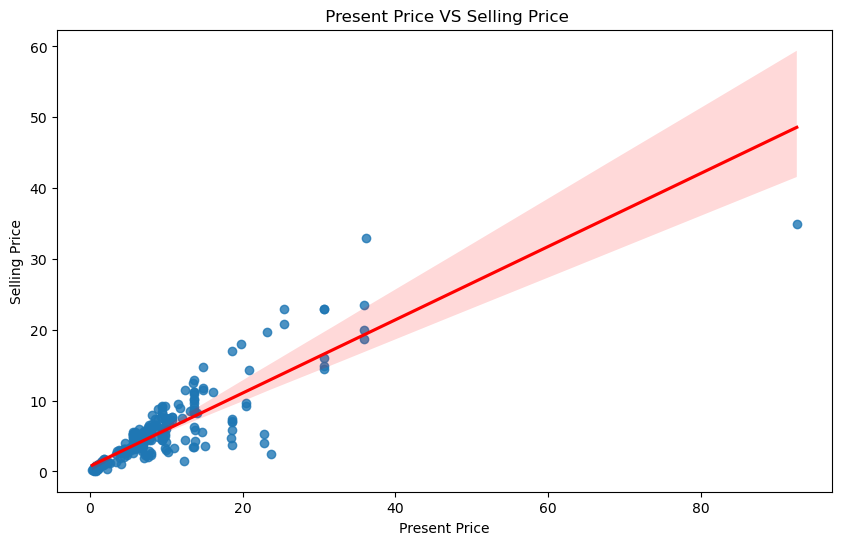

In [80]:
# present price vs selling price
plt.figure(figsize=(10, 6))

sns.regplot(
    x='Present_Price',
    y='Selling_Price',
    data=df, 
    line_kws={'color':'red'}  
)
plt.title(' Present Price VS Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

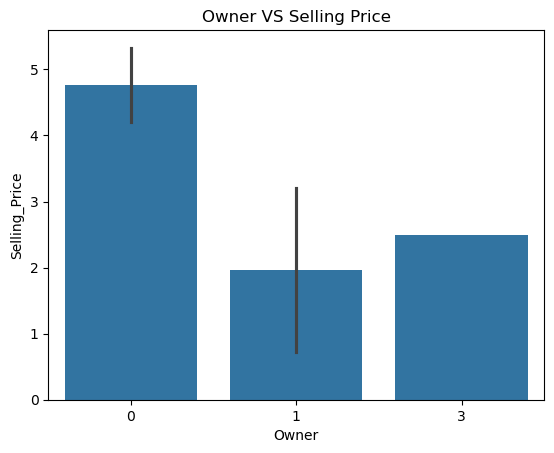

In [81]:
# selling price of car based on no. of owner
sns.barplot(x='Owner', y='Selling_Price', data=df, estimator='mean')
plt.title('Owner VS Selling Price')
plt.show()

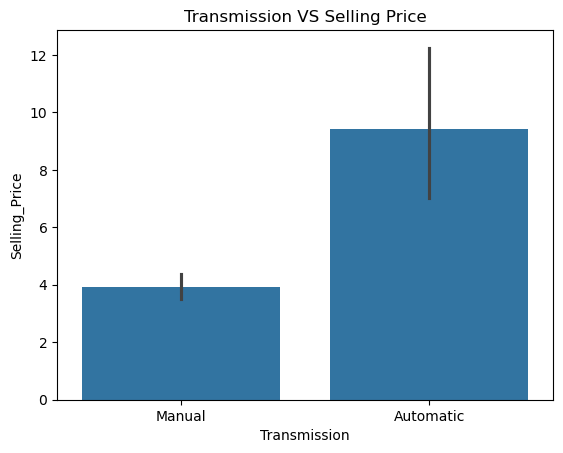

In [82]:
# selling price of car based on transmission (manual/automatic)
sns.barplot(x='Transmission', y='Selling_Price', data=df, estimator='mean')
plt.title('Transmission VS Selling Price')
plt.show()

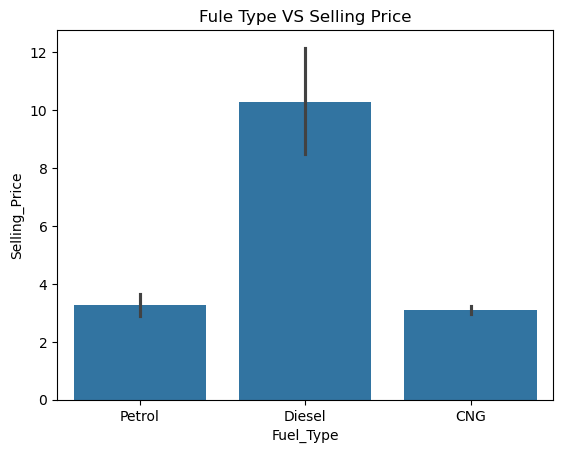

In [83]:
# price dependence on fule type
sns.barplot(x='Fuel_Type', y='Selling_Price', data=df, estimator='mean')
plt.title('Fule Type VS Selling Price')
plt.show()

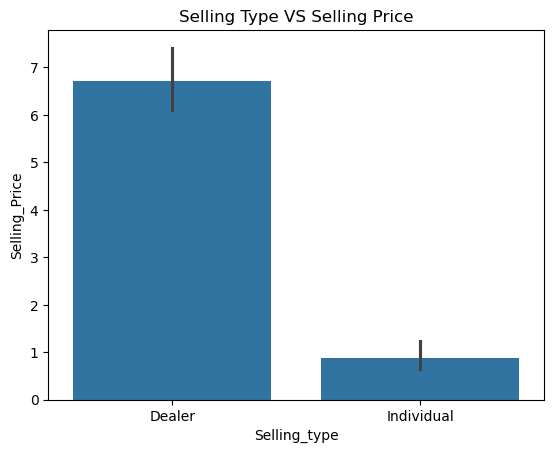

In [84]:
# selling price depend on Seller (dealer/indivisual)
sns.barplot(x='Selling_type', y='Selling_Price', data=df, estimator='mean')
plt.title('Selling Type VS Selling Price')
plt.show()

- Insights:
    - Present Price (new car price) increases, the Selling Price (used car price) also increases.
    - selling price of automatic car is more than manual
    - Fuel Type: Petrol cars dominate; diesel resale value is decreasing due to fuel price changes.
    - selling price is more if sell through Dealer than self

## 3. Feature Engineering

In [85]:
# Drop Car_Name is irllevent feature
df = df.drop(['Car_Name'], axis=1)

In [86]:
# Convert Year to Car Age 
df['Car_Age'] = 2025 - df['Year']
df.drop('Year', axis=1, inplace=True)

In [87]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [88]:
# Convert categorical features using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [89]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


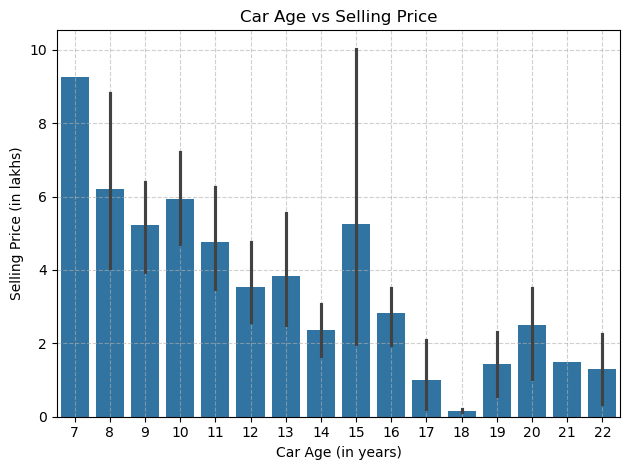

In [90]:
# Selling price depend on age of car
sns.barplot(x='Car_Age', y='Selling_Price', data=df, estimator='mean')
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (in years)")
plt.ylabel("Selling Price (in lakhs)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

- Insights:  less car age , more selling price


## 4. Split Data into Training and Testing Sets

In [91]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

## 5. Checking best fit model

In [93]:
models = {
    'linear' : LinearRegression(),
    'DecisionTree' : DecisionTreeRegressor(random_state=0),
    'Randomforest' : RandomForestRegressor(random_state=0),
    'KNN' : KNeighborsRegressor(),
    'svr' : SVR(),
    'lgbm' : LGBMRegressor(),
    'xgboost' : XGBRegressor()
}

In [94]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        'model' : name,
        'MAE' : mean_absolute_error(y_test, y_pred),
        'MSE' : mean_squared_error(y_test,y_pred),
        'RMSE' : root_mean_squared_error(y_test, y_pred),
        'R2' : r2_score(y_test, y_pred) 
    })

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 154
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 7
[LightGBM] [Info] Start training from score 4.520250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [95]:
result_df = pd.DataFrame(results)
print(result_df)

          model       MAE        MSE      RMSE        R2
0        linear  0.993941   2.163780  1.470979  0.914398
1  DecisionTree  0.704262   1.489433  1.220423  0.941076
2  Randomforest  0.621490   1.127448  1.061814  0.955397
3           KNN  4.111443  32.005918  5.657377 -0.266191
4           svr  3.434599  29.714629  5.451113 -0.175545
5          lgbm  0.796931   1.624704  1.274639  0.935725
6       xgboost  0.658527   1.157506  1.075874  0.954208


## 6. Retrain using Random Forest Regression
- Best Model: Random Forest
    - Highest R² = 0.9554 → 95.5% of the variance
    - Lowest MAE, MSE, and RMSE among all models


In [96]:
RF = RandomForestRegressor(n_estimators=200,random_state=0)
RF.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=0)

## Model Evaluation

In [97]:
y_pred = RF.predict(X_test)

print('MAE: ',  mean_absolute_error(y_test, y_pred))
print('MSE: ', mean_squared_error(y_test,y_pred))
print('RMSE: ' ,root_mean_squared_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))

MAE:  0.6156196721311482
MSE:  1.1150019623770469
RMSE:  1.055936533309198
R2:  0.9558892309215045


## Visualization

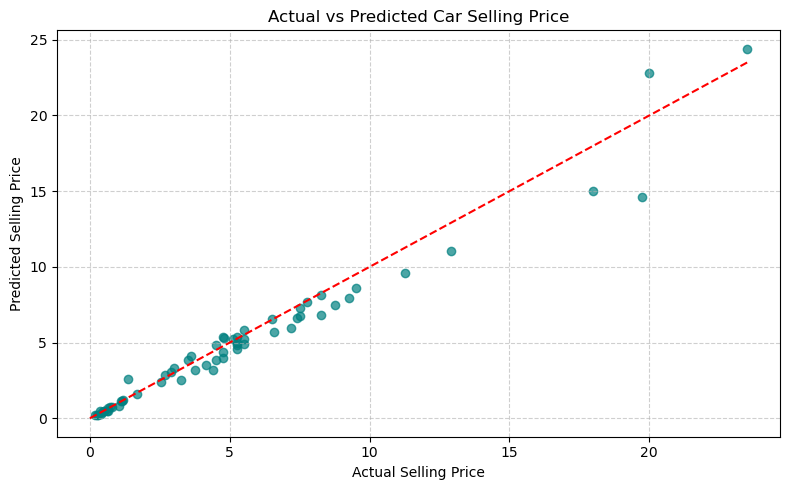

In [98]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='teal', alpha=0.7)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Selling Price")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


- Predicted prices closely match actual selling prices

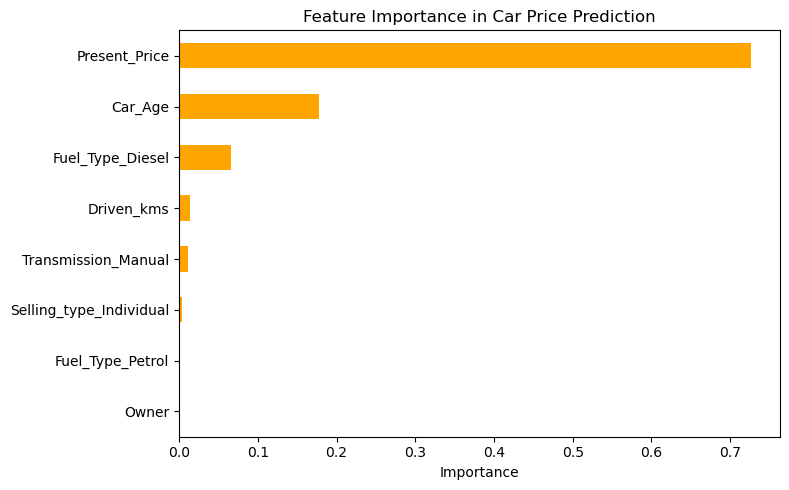

In [100]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,5), color='orange')
plt.title("Feature Importance in Car Price Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Save model

In [104]:
import joblib
joblib.dump(RF, "RandomForest.pkl")

['RandomForest.pkl']

## Conclusion:

- It aim to predict selling price of used car based on key features such as its present price, age, kilometers driven, fuel type, transmission, and ownership history.
- Performed data cleaning, feature engineering, and exploratory data analysis to identify key insights.
- key insights:
    - Present Price (new car price) increases, the Selling Price (used car price) also increases.
    - selling price of automatic car is more than manual
    - Fuel Type: Petrol cars dominate; diesel resale value is decreasing due to fuel price changes.
    - selling price is more if sell through Dealer than self
    - less car age , more selling price

- Compared multiple algorithms (Linear Regression, Decision Tree, Random Forest, XGBoost, LGBM, SVR, KNN), where Random Forest Regressor achieved the best performance (R² ≈ 0.95)
- This project builds a machine learning model that predicts used car prices with ~96% accuracy, helping buyers and sellers make smarter decisions.